# Transfer Learning using MobileNetV2

In this notebook, we will explore Transfer Learning using the MobileNetV2 architecture.
We will verify:
1.  **Feature Extraction**: Freezing all layers of the pre-trained model.
2.  **Fine Tuning**: Unfreezing the last few layers.
3.  **Prediction**: Using the pre-trained model to classify images.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import matplotlib.pyplot as plt
import os

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


## 1. Helper Function to Load and Preprocess Images
We will define a helper function to load images, resize them to (224, 224) as required by MobileNetV2, and preprocess them.

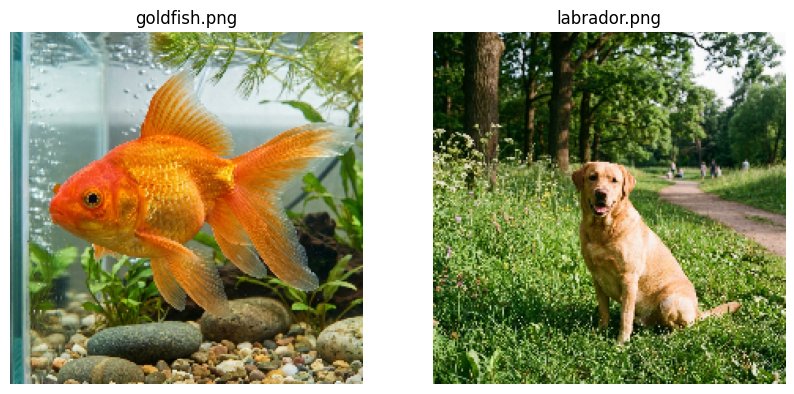

In [2]:
def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_preprocessed = preprocess_input(img_array)
    return img, img_preprocessed

# Let's inspect our sample images
image_files = ['goldfish.png', 'labrador.png']

plt.figure(figsize=(10, 5))
for i, file in enumerate(image_files):
    if os.path.exists(file):
        img, _ = load_and_preprocess_image(file)
        plt.subplot(1, 2, i+1)
        plt.imshow(img)
        plt.title(file)
        plt.axis('off')
    else:
        print(f"File not found: {file}")
plt.show()

## 2. Model 1: Feature Extraction (All Layers Frozen)

In this approach, we use the pre-trained model as a fixed feature extractor. We remove the fully connected layer at the top and add our own new classifier. We freeze all the weights of the pre-trained base.

In [3]:
# Load MobileNetV2 without the top layer
base_model_frozen = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model_frozen.trainable = False

# Create a new model on top
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_frozen(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x) # Example dense layer
outputs = tf.keras.layers.Dense(10, activation='softmax')(x) # Assuming 10 classes for this example

model_frozen = tf.keras.Model(inputs, outputs)

print("Feature Extraction Model Summary (All layers frozen):")
model_frozen.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Feature Extraction Model Summary (All layers frozen):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Model 2: Fine Tuning

In Fine Tuning, we unfreeze a few of the top layers of the frozen model base and train them jointly with the newly added classifier layers.

In [4]:
# Load MobileNetV2 without the top layer
base_model_finetune = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the base model
base_model_finetune.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model_finetune.layers[:fine_tune_at]:
    layer.trainable = False

# Create a new model on top
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_finetune(inputs, training=True) # Important to use training=True/False correctly for BatchNormalization
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model_finetune = tf.keras.Model(inputs, outputs)

print("Fine Tuning Model Summary:")
model_finetune.summary()

print(f"\nNumber of layers in the base model: {len(base_model_finetune.layers)}")
print(f"Number of trainable variables: {len(model_finetune.trainable_variables)}")

Fine Tuning Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 1,874,250 (7.15 MB)

 Non-trainable params: 396,544 (1.51 MB)


Number of layers in the base model: 154
Number of trainable variables: 56


## 4. Prediction Example

Here we use the fully pre-trained MobileNetV2 model (with weights) to classify our sample images.

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


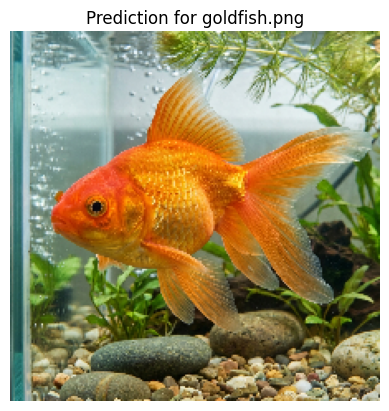

Predictions for goldfish.png:
1. goldfish: 87.25%
2. starfish: 0.35%
3. pinwheel: 0.18%
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


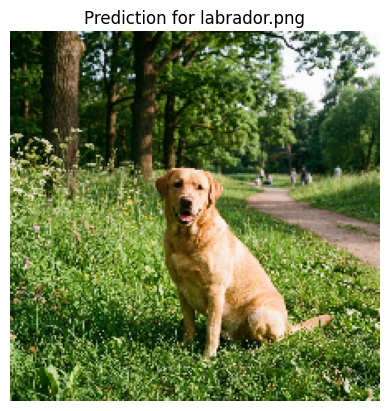

Predictions for labrador.png:
1. Labrador_retriever: 39.76%
2. golden_retriever: 36.42%
3. Chesapeake_Bay_retriever: 5.63%
------------------------------


In [5]:
# Load MobileNetV2 with the top layer (classifier) included
model_predict = MobileNetV2(weights='imagenet', include_top=True)

# Predict for our sample images
for file in image_files:
    if os.path.exists(file):
        img, img_preprocessed = load_and_preprocess_image(file)
        
        preds = model_predict.predict(img_preprocessed)
        decoded_preds = decode_predictions(preds, top=3)[0]
        
        plt.figure()
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction for {file}")
        plt.show()
        
        print(f"Predictions for {file}:")
        for i, (imagenet_id, label, score) in enumerate(decoded_preds):
            print(f"{i+1}. {label}: {score*100:.2f}%")
        print("-" * 30)